## Run the shapefile on a gerrychain.

In [1]:
import warnings
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.metrics import efficiency_gap
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from functools import partial
from gerrychain.tree import bipartition_tree
import pandas as pd


In [2]:
RI_graph = Graph.from_file("./FinalShapeFiles/RI.shp")

# CITE: https://networkx.org/documentation/stable/tutorial.html
RI_df = gpd.read_file("./FinalShapeFiles/RI.shp")



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gerrychain/graph/graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {91}
  warnings.warn(


In [3]:
# Check if the dual graph is connected
is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: False


Make the dual graph connected by connecting the isolated Island.

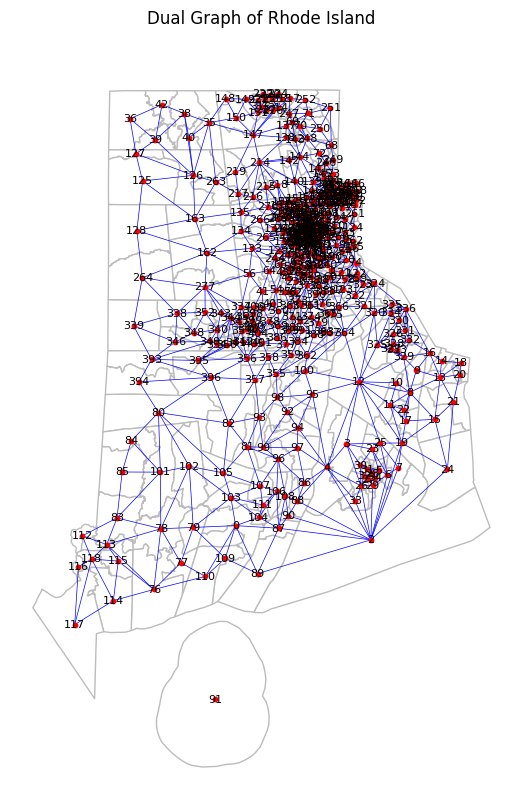

In [4]:
#plot graph
fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}


nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        labels={node: node for node in RI_graph.nodes},
        font_size=8,         
        width=0.5
)

plt.title("Dual Graph of Rhode Island")
plt.show()

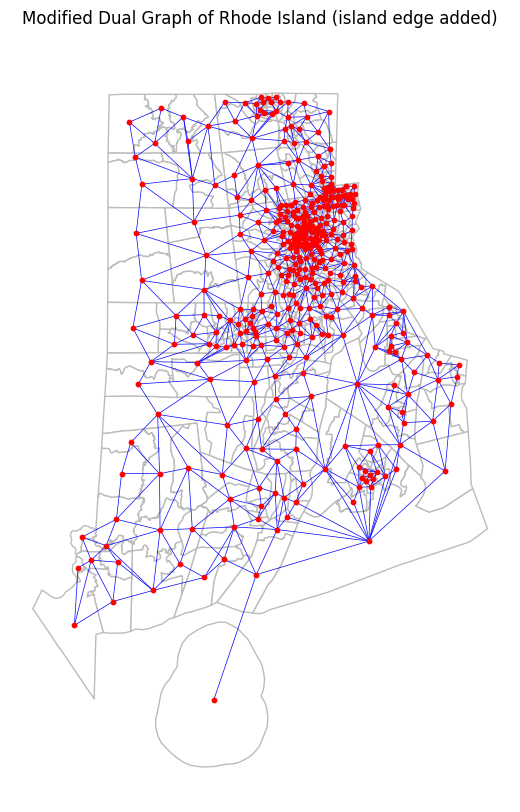

In [5]:
# Add a single edge to connect Block Island (node 91, 'New Shoreham 1') to
# its nearest mainland precinct (node 89, 'Narragansett 5').
RI_graph.add_edge(89, 91)
           
# draw the graph again to verify
fig, ax = plt.subplots(figsize=(10, 10))

RI_df.plot(ax=ax, color="white", edgecolor="#bcbcbc")

# get the centriod of each place
pos = {node: (RI_df.geometry[node].centroid.x, RI_df.geometry[node].centroid.y) for node in RI_graph.nodes}

nx.draw(RI_graph, 
        pos, 
        ax=ax, 
        node_size=10, 
        node_color="red", 
        edge_color="blue", 
        width=0.5
)

plt.title("Modified Dual Graph of Rhode Island (island edge added)")
plt.show()

In [6]:

is_contig = nx.is_connected(RI_graph)
print(f"Dual graph is connected or not: {is_contig}")

Dual graph is connected or not: True


In [7]:
# island population and its share of Rhode Island's total
island_node = 91
mainland_node = 89

island_pop = int(RI_df.iloc[island_node]["TOTPOP"])
state_pop  = int(RI_df["TOTPOP"].sum())

print(f"Island precinct (node {island_node}, {RI_df.iloc[island_node]['NAME20']}) population: {island_pop:,}")
print(f"Rhode Island statewide population (2020 Census): {state_pop:,}")
print(f"Island share of state population: {100 * island_pop / state_pop:.3f}%")
print(f"Mainland precinct it is connected to (node {mainland_node}): {RI_df.iloc[mainland_node]['NAME20']}")

Island precinct (node 91, New Shoreham 1) population: 1,410
Rhode Island statewide population (2020 Census): 1,097,379
Island share of state population: 0.128%
Mainland precinct it is connected to (node 89): Narragansett 5


### Visualizing the 2022 Enacted RI State Senate Map

Before running the ensemble we render the enacted plan from the precinct-level shapefile, dissolved to district boundaries and colored by district number (`SEND`). This is the map our 40,000-step ensemble will be compared against.


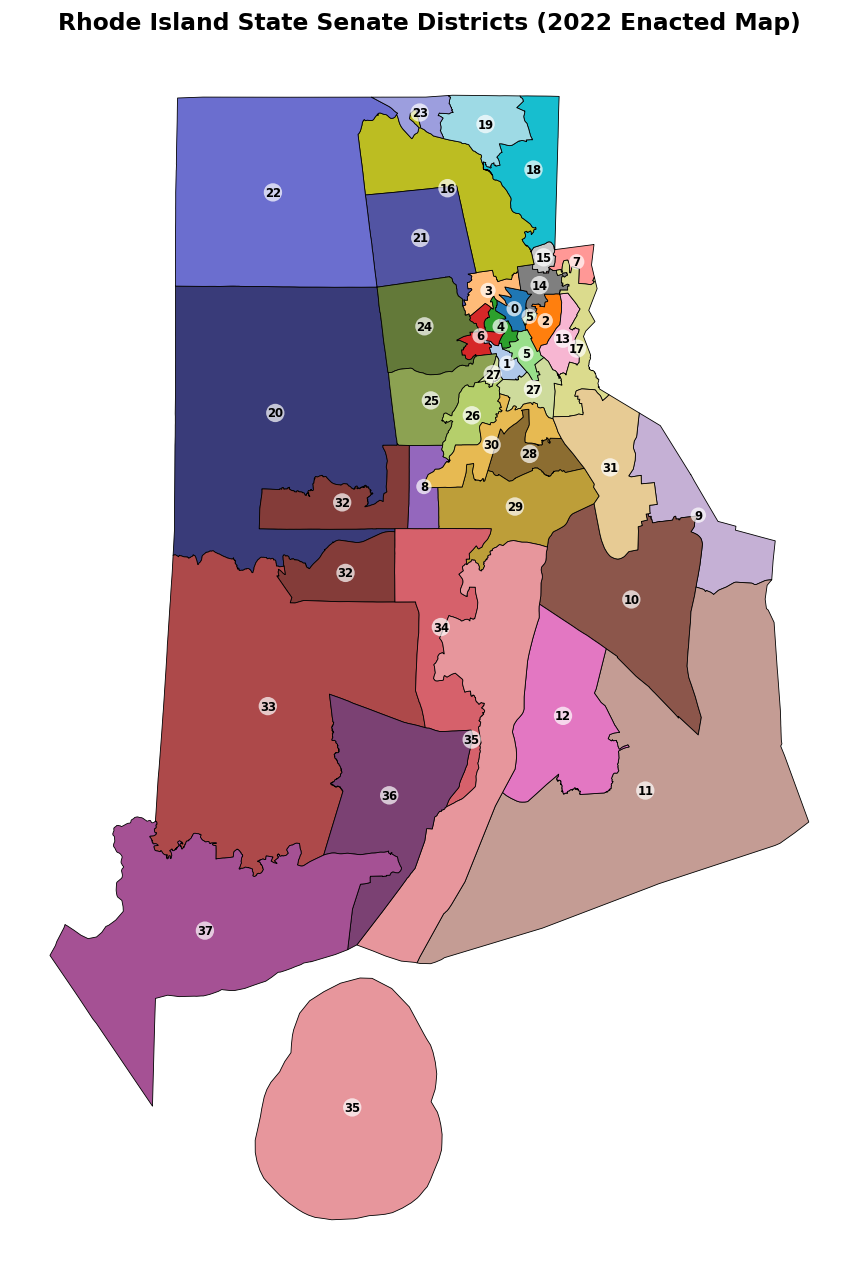

Rendered 38 senate districts from 423 precincts.


In [8]:
# 2022 enacted RI State Senate map
# colors each district with a distinct color, and labels district numbers.

from shapely.geometry import MultiPolygon
from matplotlib.colors import ListedColormap
import matplotlib

#  38-color palette by combining matplotlib qualitative colormaps.

_palette = (
    list(matplotlib.colormaps["tab20"].colors) +
    list(matplotlib.colormaps["tab20b"].colors) +
    list(matplotlib.colormaps["tab20c"].colors)
)
DISTRICT_CMAP = ListedColormap(_palette[:38])

ri_for_map = gpd.read_file("./FinalShapeFiles/RI.shp")
districts  = ri_for_map.dissolve(by="SEND").reset_index()
districts["SEND"] = districts["SEND"].astype(int)

fig, ax = plt.subplots(figsize=(9, 11), dpi=120)
districts.plot(
    ax=ax,
    column="SEND",
    cmap=DISTRICT_CMAP,
    edgecolor="black",
    linewidth=0.5,
    categorical=True,
)

# Labeled all geometry parts so multi-polygons show their district number.
for _, row in districts.iterrows():
    geom = row.geometry
    parts = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    largest_area = max(p.area for p in parts)
    for part in parts:
        if part.area >= 0.01 * largest_area:
            c = part.centroid
            ax.annotate(
                str(row["SEND"]),
                xy=(c.x, c.y),
                ha="center", va="center",
                fontsize=7, fontweight="bold",
                bbox=dict(boxstyle="circle,pad=0.1",
                          facecolor="white", edgecolor="none", alpha=0.7),
            )

ax.set_title("Rhode Island State Senate Districts (2022 Enacted Map)",
             fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("enacted_senate_map.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Rendered {len(districts)} senate districts from {len(ri_for_map)} precincts.")


### Creating at least 2 Markov Chain ensembles using ReCom 
1. Use 2020 Presidential Election (G20PREDBID (Democrat), G20PRERTRU(Republican))
2. Use 2020 U.S. Senate Election (G20USSDREE (Democrat), G20USSRWAT(Republican))

In [9]:
# 1. 2020 Presidential Election
pres_election = Election(
    "Pres20",
    {"Dem": "PRES20D", "Rep": "PRES20R"}
)

# 2. 2020 U.S. Senate Election
senate_election = Election(
    "Sen20",
    {"Dem": "SEN20D", "Rep": "SEN20R"}
)

my_updaters = {
    "population": Tally("TOTPOP", alias="population"), 
    "cut_edges": cut_edges,
    "VAP": Tally("VAP", alias="VAP"),
    "HVAP": Tally("HVAP", alias="HVAP"),
    # "BVAP": Tally("BVAP", alias="BVAP"),
    "Pres20": pres_election,
    "Sen20": senate_election,

    # Get the efficiency gap
    "eff_gap_pres": lambda p: efficiency_gap(p["Pres20"]),
    "eff_gap_sen": lambda p: efficiency_gap(p["Sen20"])
}

initial_partition = Partition(
    RI_graph,              
    assignment="SEND",      
    updaters=my_updaters
)

### Granularity Analysis (justification for `pop_tolerance`)

Rhode Island's precincts are large relative to its 38 senate districts. The histogram below shows what fraction of an ideal district each precinct represents. Any precinct above the red dashed line (10%) is, by itself, large enough to make the strict ±10% legal limit infeasible, since moving that precinct between districts swings their populations by more than 10 points. This is why we relax `pop_tolerance` to 0.28 — high enough that ReCom can find valid spanning trees, low enough that population deviations stay within reasonable bounds.


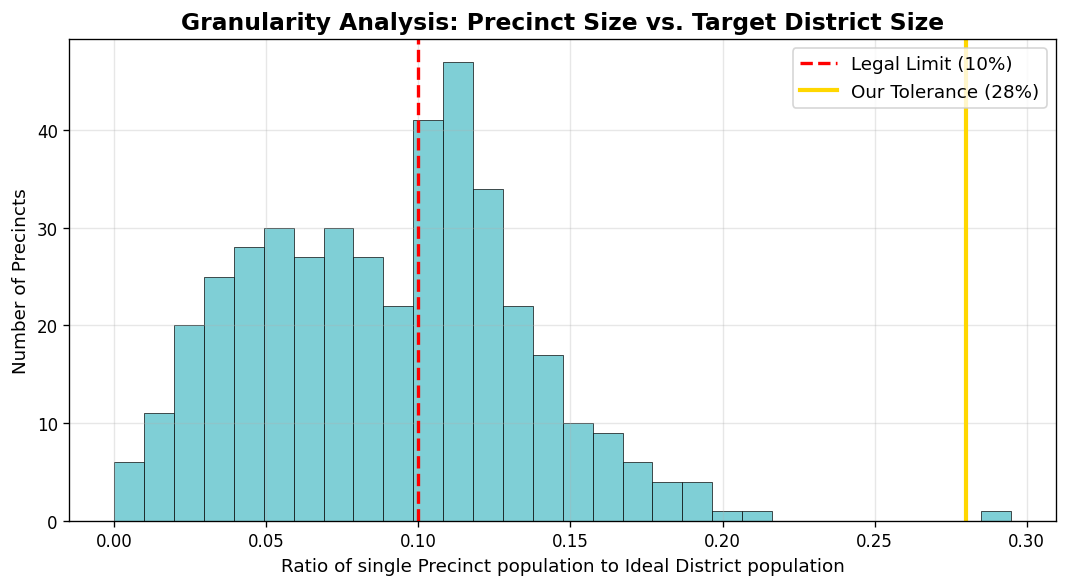

State population: 1,097,379
Ideal district population: 28,878
Precincts > 10% of an ideal district: 188 of 423
Largest single precinct ratio: 0.295


In [10]:

BAR_COLOR  = "#7fcfd6"
EDGE_COLOR = "black"
EDGE_WIDTH = 0.4

ri_for_gran = gpd.read_file("./FinalShapeFiles/RI.shp")
total_pop_state = ri_for_gran["TOTPOP"].sum()
ideal_district  = total_pop_state / 38      # 38 RI senate districts
size_ratios     = ri_for_gran["TOTPOP"] / ideal_district

LEGAL_LIMIT  = 0.10   # ±10% — the legal target for state legislative districts
OUR_EPSILON  = 0.28

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
ax.hist(size_ratios, bins=30, color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
ax.axvline(LEGAL_LIMIT, color="red",  linestyle="--", linewidth=2.0, label=f"Legal Limit ({int(LEGAL_LIMIT*100)}%)")
ax.axvline(OUR_EPSILON, color="gold", linestyle="-",  linewidth=2.5, label=f"Our Tolerance ({int(OUR_EPSILON*100)}%)")
ax.set_title("Granularity Analysis: Precinct Size vs. Target District Size",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Ratio of single Precinct population to Ideal District population", fontsize=11)
ax.set_ylabel("Number of Precincts", fontsize=11)
ax.legend(fontsize=11, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("granularity_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# numeric summary printed below the plot
n_over_legal = int((size_ratios > LEGAL_LIMIT).sum())
print(f"State population: {total_pop_state:,}")
print(f"Ideal district population: {ideal_district:,.0f}")
print(f"Precincts > 10% of an ideal district: {n_over_legal} of {len(size_ratios)}")
print(f"Largest single precinct ratio: {size_ratios.max():.3f}")


In [11]:
ri_data = gpd.read_file("./FinalShapeFiles/RI.shp")
district_summary = ri_data.groupby("SEND")["TOTPOP"].sum()

total_population = district_summary.sum()
number_of_districts = len(district_summary)

ideal_pop = total_population / number_of_districts

initial_partition = Partition(
    RI_graph,
    assignment="SEND",
    updaters=my_updaters
)

# Check population deviation
max_dev = max(
    abs((pop - ideal_pop) / ideal_pop)
    for pop in initial_partition["population"].values()
)
print("Max deviation:", max_dev)

# VEST-precinct / census-block boundary
#10% was not enough due to boundary mismatch, so we used the smallest tolerance that works
pop_tolerance = 0.28
rw_proposal = partial(recom, ## how you choose a next districting plan
                      pop_col = "TOTPOP", ## What data describes population
                      pop_target = ideal_pop, ## What the target/ideal population is for each district
                                              ## (we calculated ideal pop above)
                      epsilon = pop_tolerance,  ## how far from ideal population you can deviate
                                              ## (we set pop_tolerance above)
                      node_repeats = 20, ## number of times to repeat bipartition.  Can increase if you get a BipartitionWarning
                      method=partial(
                            bipartition_tree,
                            max_attempts=1000,
                            allow_pair_reselection=True
                        )
                      )

Max deviation: 0.26904560776176684


### Enacted Map Reference Values (for histogram overlays)


In [12]:
# Compute enacted-map metric values from the initial partition.
enacted_cut_edges        = len(initial_partition["cut_edges"])
enacted_pres_dem_seats   = initial_partition["Pres20"].wins("Dem")
enacted_sen_dem_seats    = initial_partition["Sen20"].wins("Dem")
enacted_pres_eg          = initial_partition["eff_gap_pres"]
enacted_sen_eg           = initial_partition["eff_gap_sen"]

enacted_latino_districts = 0
for dist in initial_partition["HVAP"]:
    if initial_partition["VAP"][dist] > 0:
        if initial_partition["HVAP"][dist] / initial_partition["VAP"][dist] >= 0.5:
            enacted_latino_districts += 1

print("=== 2022 enacted RI State Senate map ===")
print(f"Cut edges:                      {enacted_cut_edges}")
print(f"Dem-won seats (Pres 2020):      {enacted_pres_dem_seats}")
print(f"Dem-won seats (U.S. Sen 2020):  {enacted_sen_dem_seats}")
print(f"Efficiency Gap (Pres 2020):     {enacted_pres_eg:.4f}")
print(f"Efficiency Gap (U.S. Sen 2020): {enacted_sen_eg:.4f}")
print(f"Latino-majority districts:      {enacted_latino_districts}")

=== 2022 enacted RI State Senate map ===
Cut edges:                      498
Dem-won seats (Pres 2020):      33
Dem-won seats (U.S. Sen 2020):  37
Efficiency Gap (Pres 2020):     0.1391
Efficiency Gap (U.S. Sen 2020): 0.1367
Latino-majority districts:      3


Evidence of convergence (that you have run the chain long enough)

In [13]:
population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition,
    pop_tolerance
)

our_random_walk = MarkovChain(
    proposal = rw_proposal, 
    constraints = [population_constraint], # Could add additional constraints here
    accept = always_accept, # Accept every proposed plan that meets the population constraints
    initial_state = initial_partition, 
    total_steps = 40000)  

rows = []

In [14]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for part in our_random_walk:
        num_lat_majority = 0
        for dist in part["HVAP"]:
            if part["VAP"][dist] > 0:
                hvap_share = part["HVAP"][dist] / part["VAP"][dist]
                if hvap_share >= 0.5:
                    num_lat_majority += 1

        rows.append({
            "pres_dem_seats":   part["Pres20"].wins("Dem"),
            "sen_dem_seats":    part["Sen20"].wins("Dem"),
            "cut_edges":        len(part["cut_edges"]),
            "pres_eg":          part["eff_gap_pres"],
            "sen_eg":           part["eff_gap_sen"],
            "latino_districts": num_lat_majority,
        })

ensemble_df = pd.DataFrame(rows)
ensemble_df.to_csv("ensemble_results.csv", index=False)

# expose the ensemble columns as lists so the histogram cell below
pres_dem_seats            = ensemble_df["pres_dem_seats"].tolist()
sen_dem_seats             = ensemble_df["sen_dem_seats"].tolist()
cutedge_ensemble          = ensemble_df["cut_edges"].tolist()
pres_eg_scores            = ensemble_df["pres_eg"].tolist()
sen_eg_scores             = ensemble_df["sen_eg"].tolist()
latino_districts_ensemble = ensemble_df["latino_districts"].tolist()

print(f"Saved ensemble_results.csv with {len(ensemble_df):,} rows.")
ensemble_df.head()


Saved ensemble_results.csv with 40,000 rows.


,pres_dem_seats,sen_dem_seats,cut_edges,pres_eg,sen_eg,latino_districts
0,33,37,498,0.139083,0.13672,3
1,33,37,498,0.139083,0.13672,3
2,33,37,499,0.139083,0.13672,3
3,33,37,499,0.139083,0.13672,3
4,33,37,499,0.139083,0.13672,3


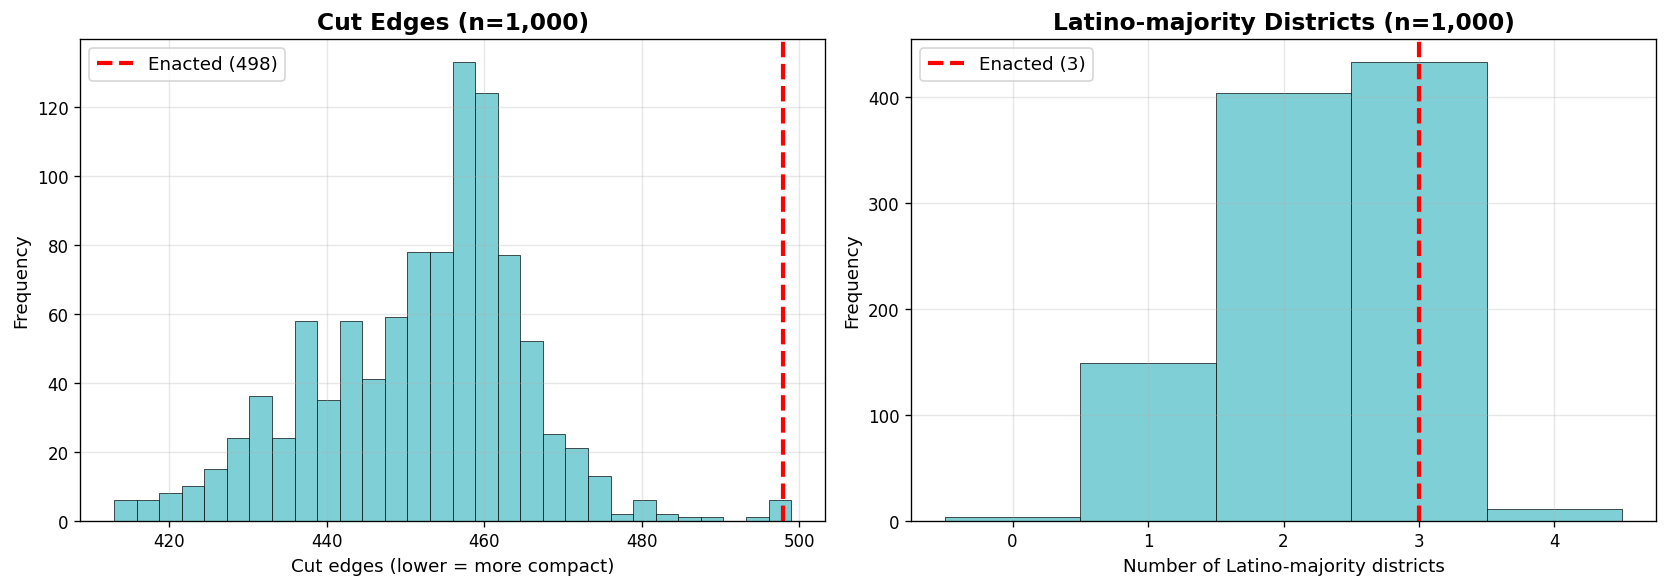

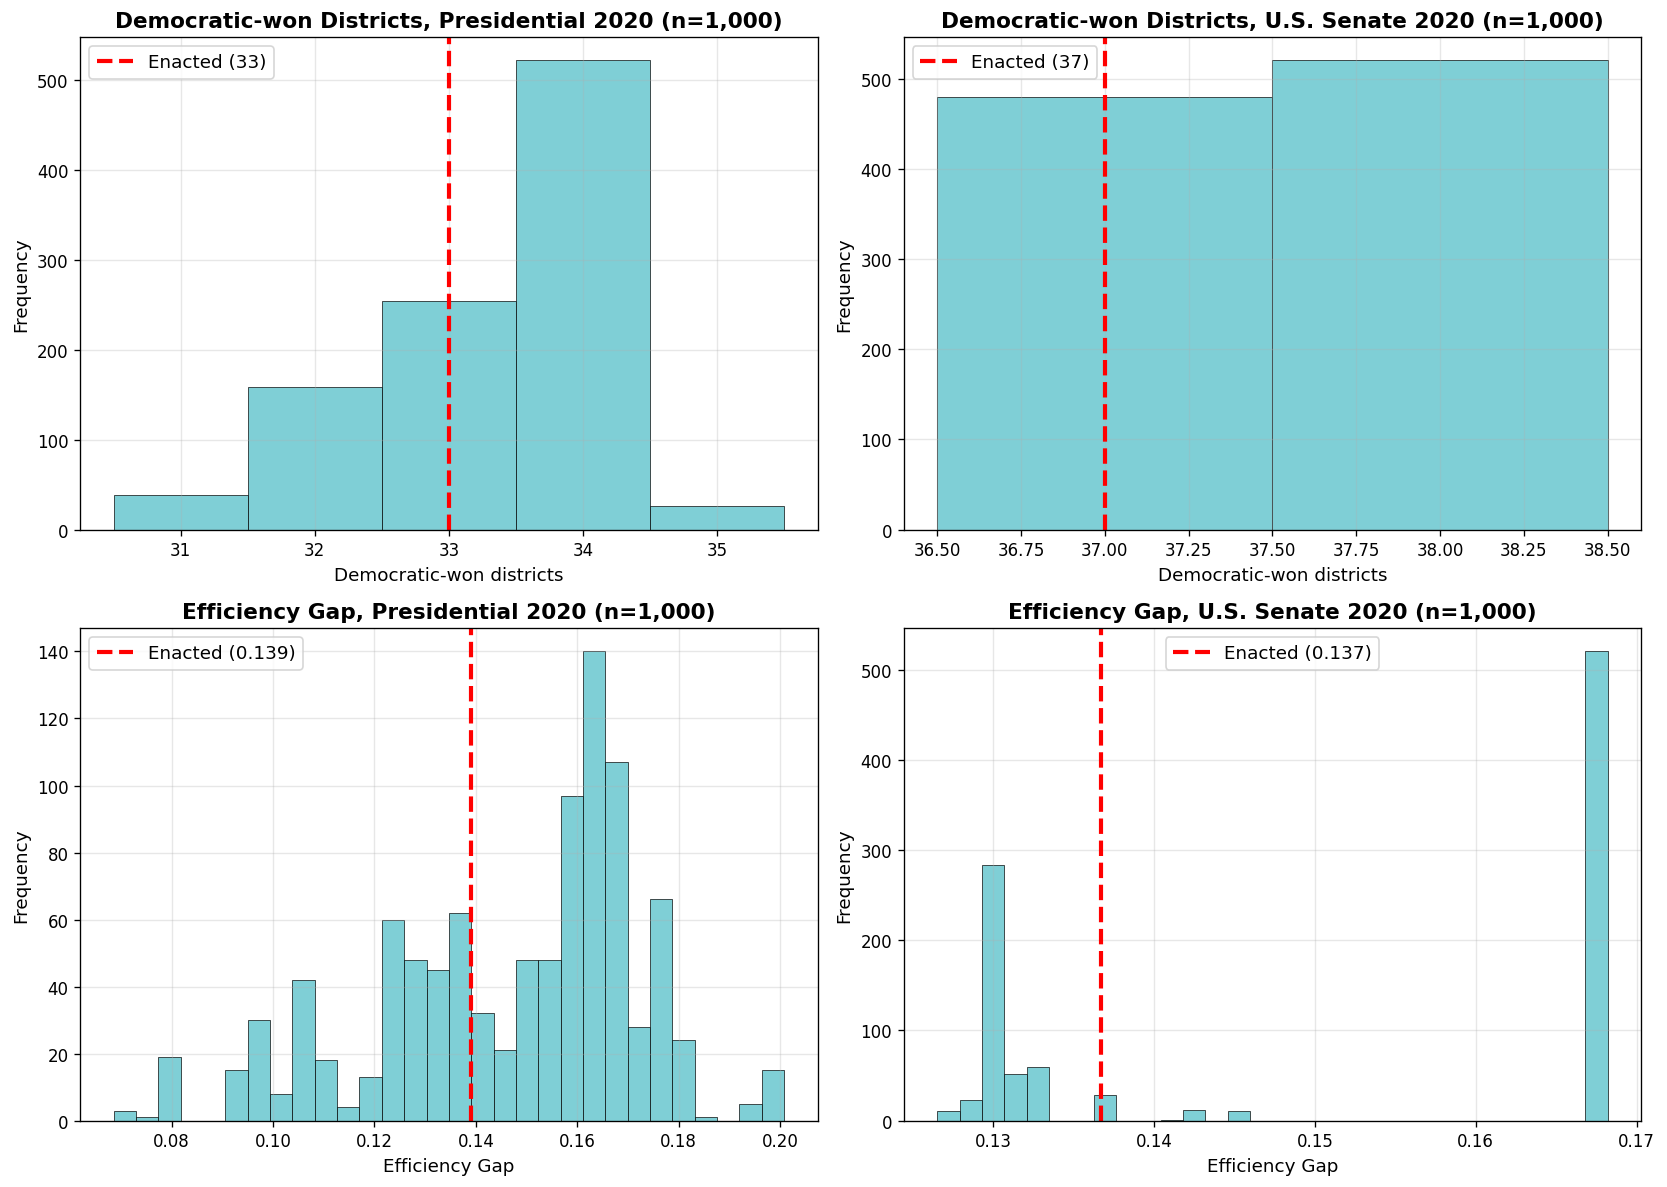

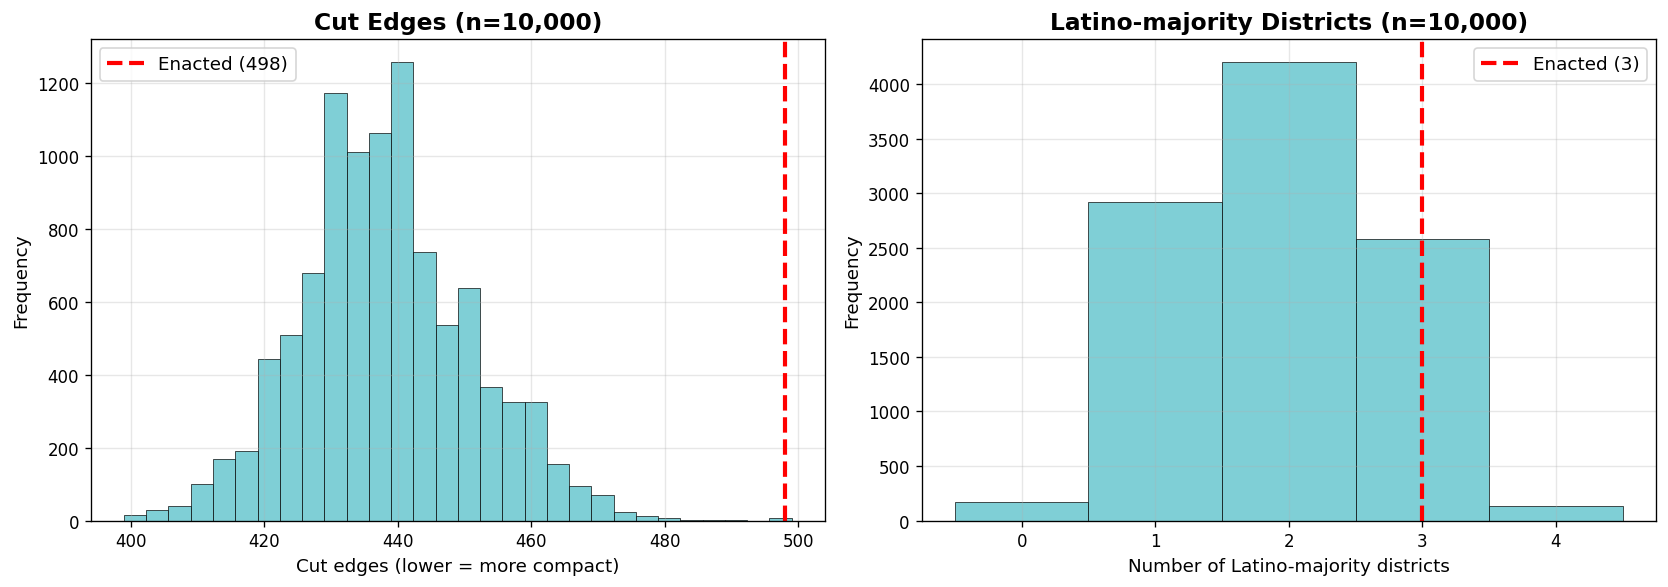

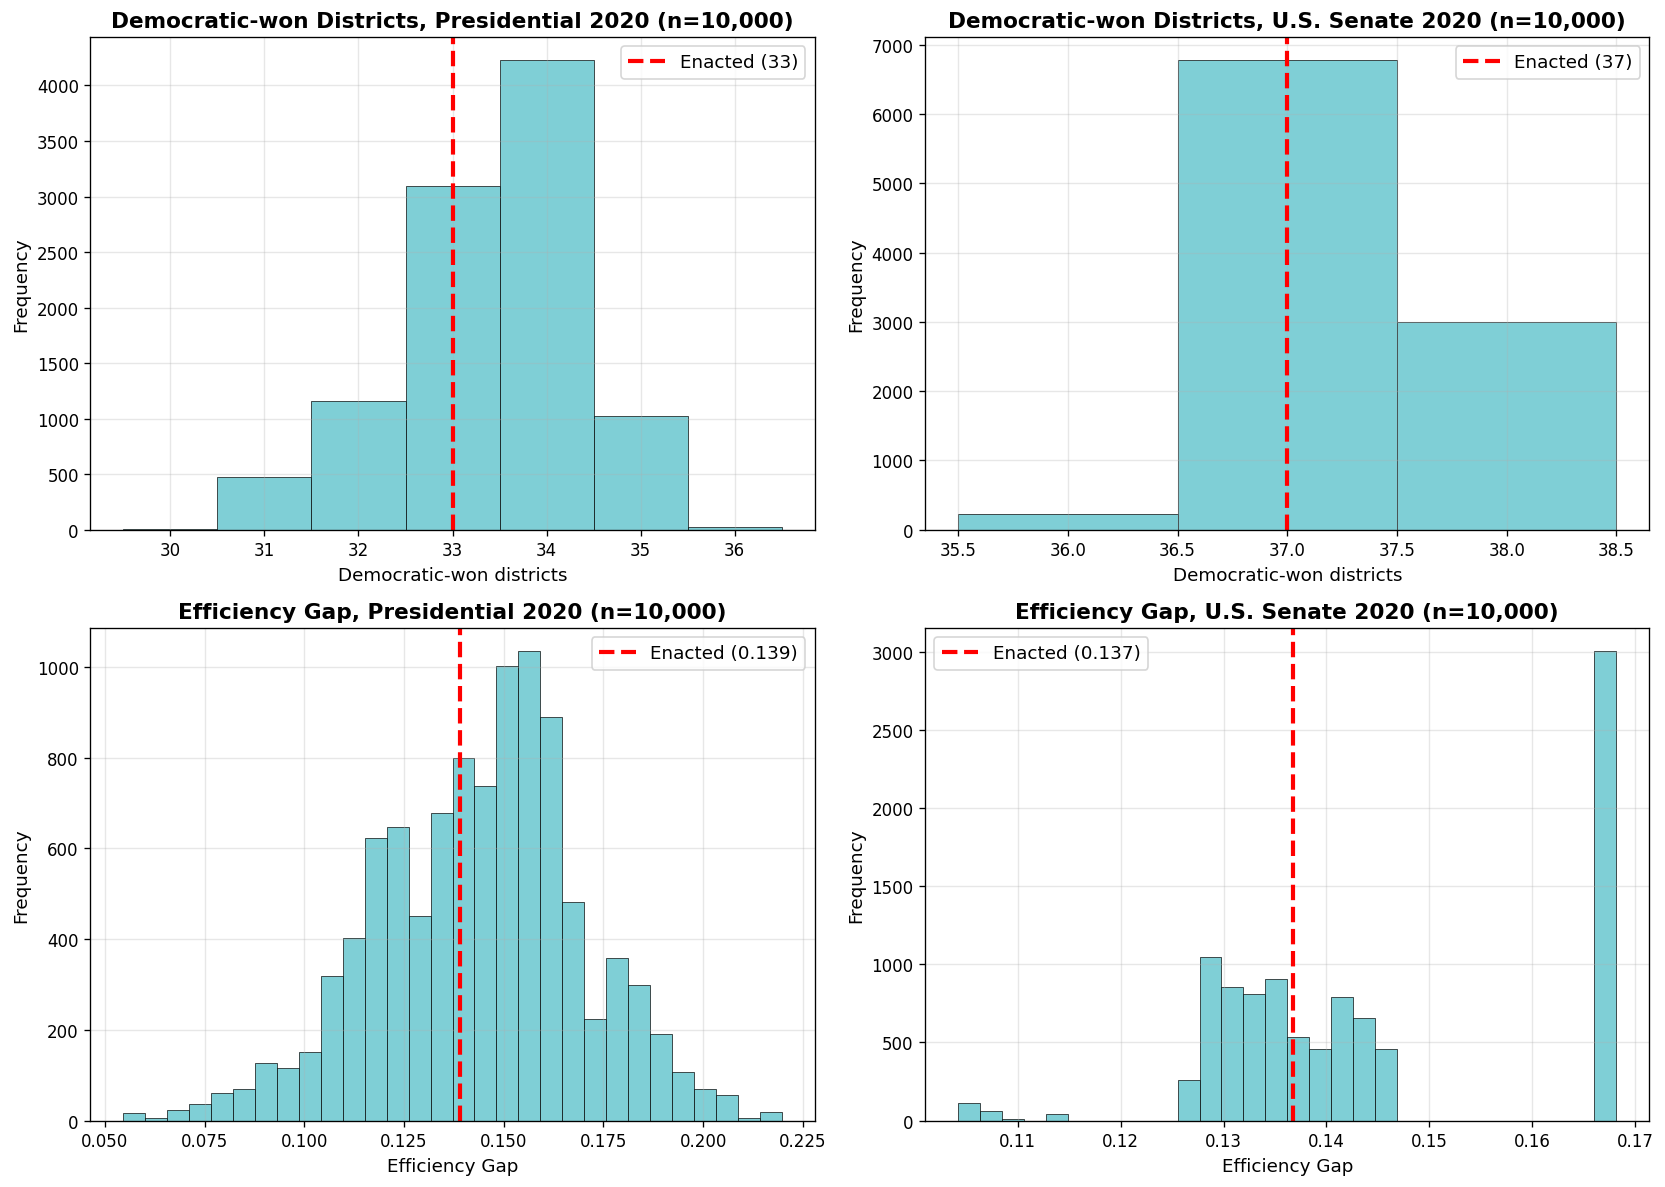

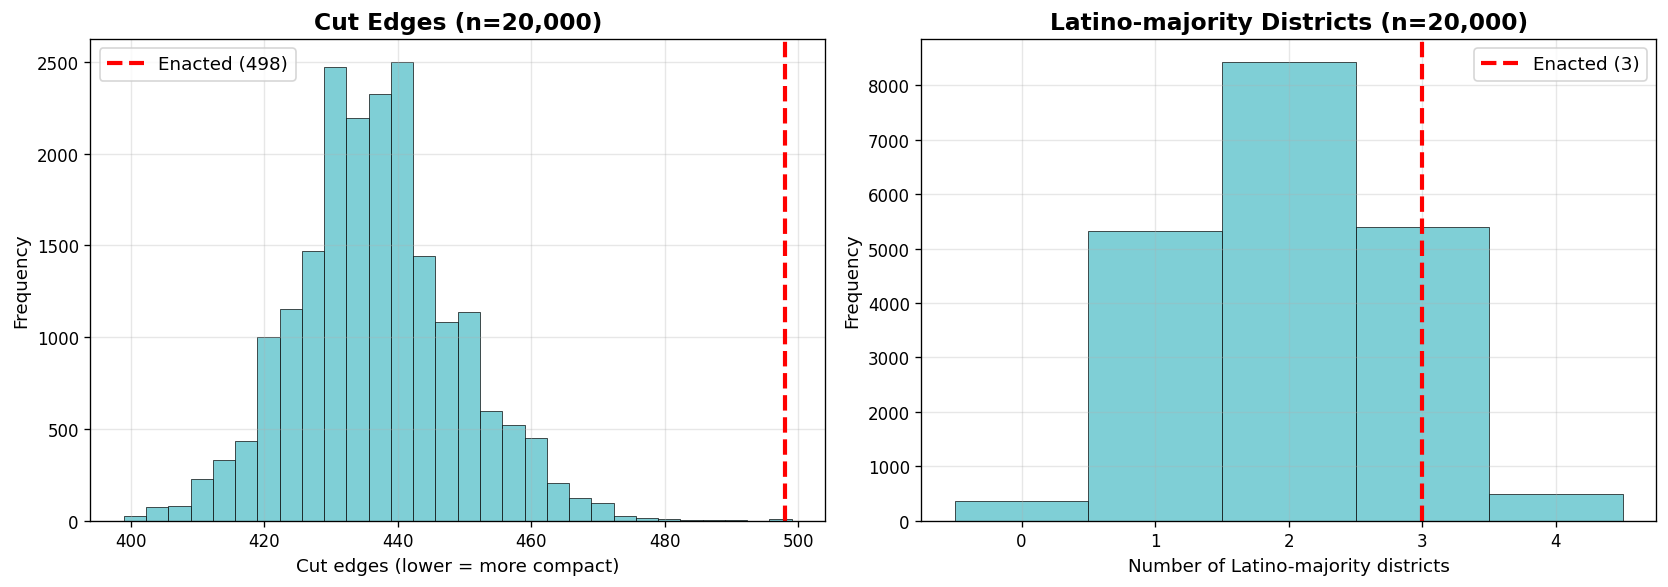

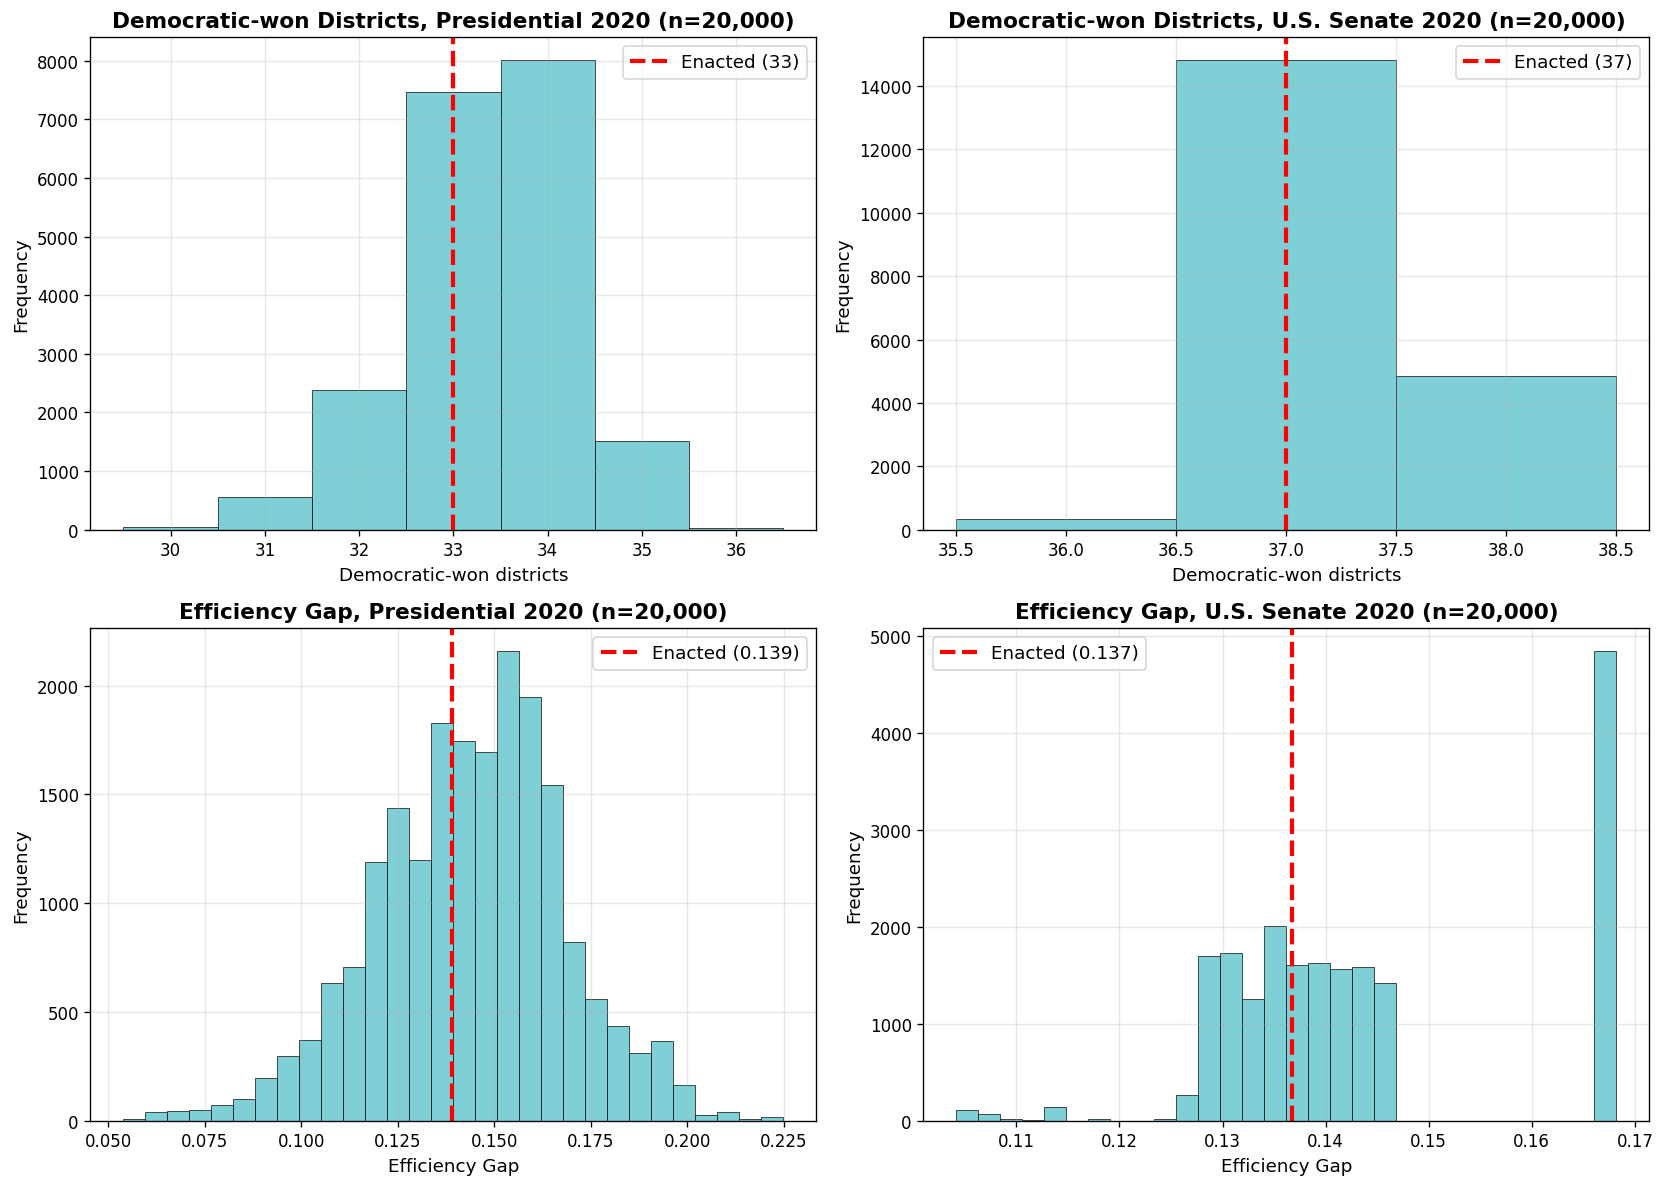

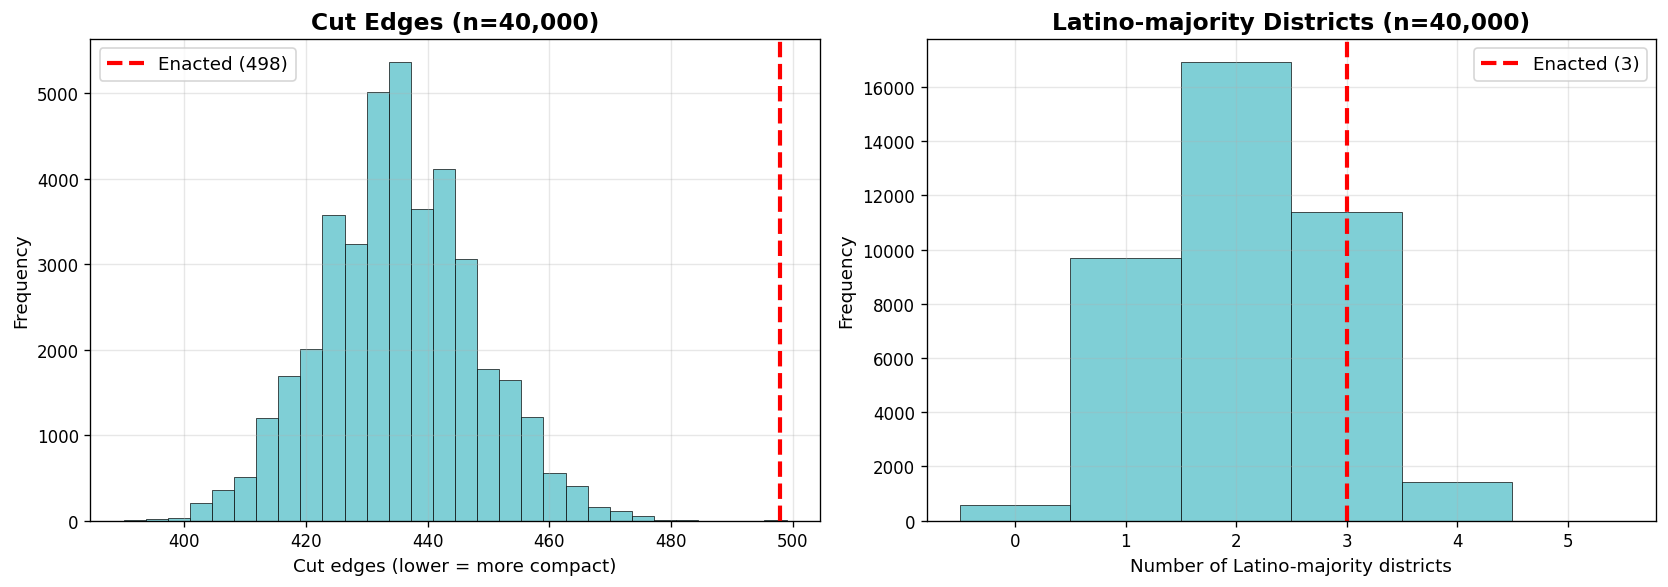

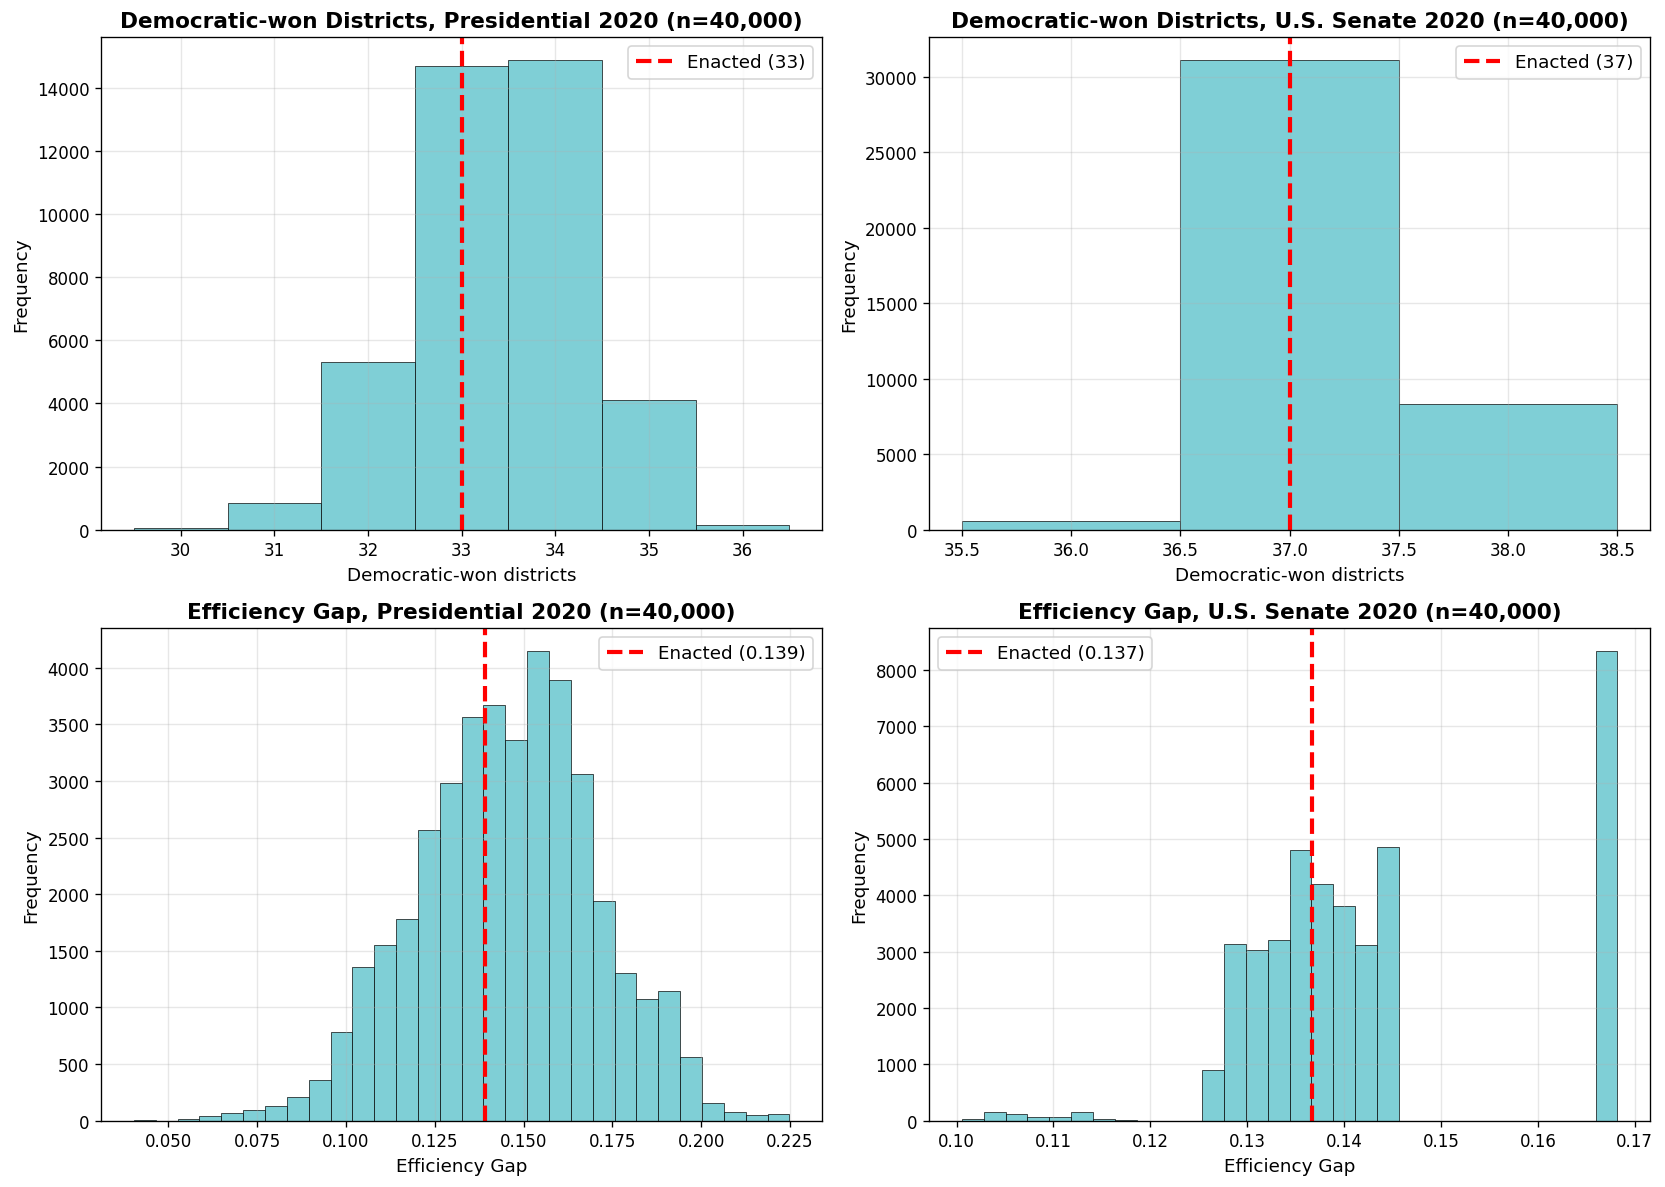

In [15]:
# Histograms with enacted-map reference line
# Each subplot shows the ensemble distribution; the red dashed line marks
# the value from the 2022 enacted RI Senate map.

# style settings
BAR_COLOR  = "#7fcfd6"   # teal
EDGE_COLOR = "black"
EDGE_WIDTH = 0.4
LINE_COLOR = "red"
TITLE_FS   = 14
LABEL_FS   = 11
LEG_FS     = 11

for size in [1000, 10000, 20000, 40000]:
    #Cut edges + Latino-majority districts
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    # Cut edges
    ax = axes[0]
    ax.hist(cutedge_ensemble[:size], bins=30,
            color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    ax.axvline(enacted_cut_edges, color=LINE_COLOR, linestyle="--", linewidth=2.5,
               label=f"Enacted ({enacted_cut_edges})")
    ax.set_title(f"Cut Edges (n={size:,})", fontsize=TITLE_FS, fontweight="bold")
    ax.set_xlabel("Cut edges (lower = more compact)", fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.legend(fontsize=LEG_FS)
    ax.grid(alpha=0.3)

    # Latino-majority districts
    ax = axes[1]
    max_lat = max(latino_districts_ensemble[:size]) + 2
    ax.hist(latino_districts_ensemble[:size],
            bins=range(0, max_lat), align="left",
            color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    ax.axvline(enacted_latino_districts, color=LINE_COLOR, linestyle="--", linewidth=2.5,
               label=f"Enacted ({enacted_latino_districts})")
    ax.set_title(f"Latino-majority Districts (n={size:,})", fontsize=TITLE_FS, fontweight="bold")
    ax.set_xlabel("Number of Latino-majority districts", fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.legend(fontsize=LEG_FS)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if size == 40000:
        plt.savefig("cutedges_latino_hist.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

    # Partisan: Dem seats + Efficiency Gap
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

    # Pres Dem seats
    ax = axes[0][0]
    ax.hist(pres_dem_seats[:size],
            bins=range(min(pres_dem_seats[:size]), max(pres_dem_seats[:size]) + 2),
            align="left", color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    ax.axvline(enacted_pres_dem_seats, color=LINE_COLOR, linestyle="--", linewidth=2.5,
               label=f"Enacted ({enacted_pres_dem_seats})")
    ax.set_title(f"Democratic-won Districts, Presidential 2020 (n={size:,})",
                 fontsize=TITLE_FS - 1, fontweight="bold")
    ax.set_xlabel("Democratic-won districts", fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.legend(fontsize=LEG_FS)
    ax.grid(alpha=0.3)

    # Senate Dem seats
    ax = axes[0][1]
    ax.hist(sen_dem_seats[:size],
            bins=range(min(sen_dem_seats[:size]), max(sen_dem_seats[:size]) + 2),
            align="left", color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    ax.axvline(enacted_sen_dem_seats, color=LINE_COLOR, linestyle="--", linewidth=2.5,
               label=f"Enacted ({enacted_sen_dem_seats})")
    ax.set_title(f"Democratic-won Districts, U.S. Senate 2020 (n={size:,})",
                 fontsize=TITLE_FS - 1, fontweight="bold")
    ax.set_xlabel("Democratic-won districts", fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.legend(fontsize=LEG_FS)
    ax.grid(alpha=0.3)

    # Pres EG
    ax = axes[1][0]
    ax.hist(pres_eg_scores[:size], bins=30,
            color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    ax.axvline(enacted_pres_eg, color=LINE_COLOR, linestyle="--", linewidth=2.5,
               label=f"Enacted ({enacted_pres_eg:.3f})")
    ax.set_title(f"Efficiency Gap, Presidential 2020 (n={size:,})",
                 fontsize=TITLE_FS - 1, fontweight="bold")
    ax.set_xlabel("Efficiency Gap", fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.legend(fontsize=LEG_FS)
    ax.grid(alpha=0.3)

    # Senate EG
    ax = axes[1][1]
    ax.hist(sen_eg_scores[:size], bins=30,
            color=BAR_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    ax.axvline(enacted_sen_eg, color=LINE_COLOR, linestyle="--", linewidth=2.5,
               label=f"Enacted ({enacted_sen_eg:.3f})")
    ax.set_title(f"Efficiency Gap, U.S. Senate 2020 (n={size:,})",
                 fontsize=TITLE_FS - 1, fontweight="bold")
    ax.set_xlabel("Efficiency Gap", fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.legend(fontsize=LEG_FS)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if size == 40000:
        plt.savefig("Markov40000.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


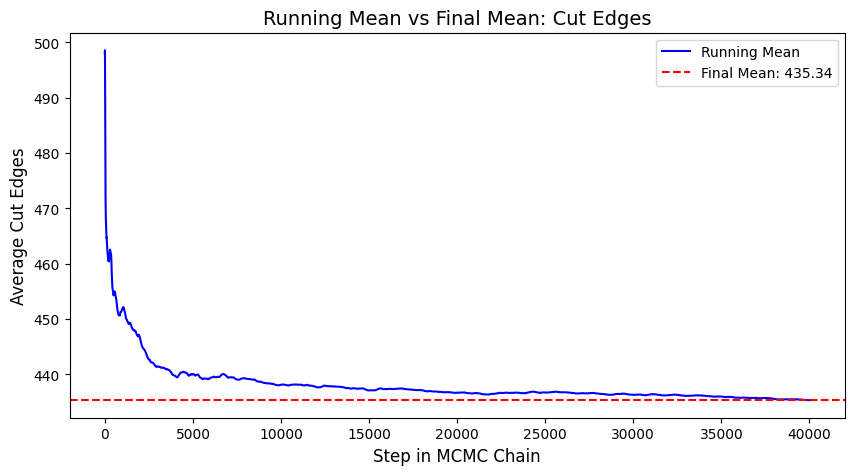

In [16]:
#Convergence plots
#Blue line = running mean up to each step
#Red dashed line = final mean after all steps
# Plot running mean to show the chain has run long enough
import pandas as pd
import matplotlib.pyplot as plt
ensemble_df = pd.read_csv("ensemble_results.csv")

plt.figure(figsize=(10, 5))
running_mean = ensemble_df["cut_edges"].expanding().mean()
final_mean = running_mean.iloc[-1]

plt.plot(running_mean, label="Running Mean", color='blue', linewidth=1.5)
plt.axhline(y=final_mean, color='red', linestyle='--', label=f"Final Mean: {final_mean:.2f}")

plt.title("Running Mean vs Final Mean: Cut Edges", fontsize=14)
plt.xlabel("Step in MCMC Chain", fontsize=12)
plt.ylabel("Average Cut Edges", fontsize=12)
plt.legend()
plt.show()


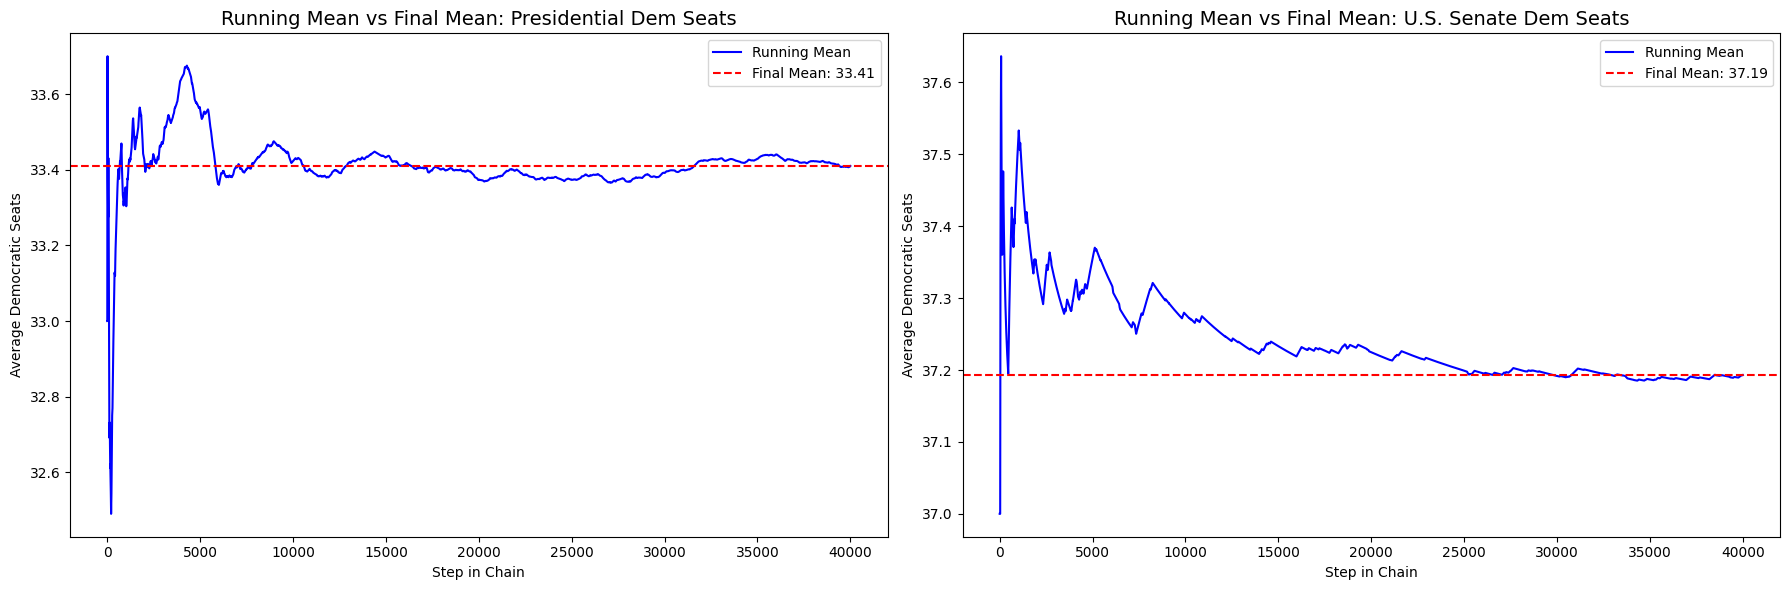

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
#Convergence plots
#Blue line = running mean up to each step
#Red dashed line = final mean after all steps
# Presidential 2020 seats Convergence
pres_running_mean = ensemble_df["pres_dem_seats"].expanding().mean()
axes[0].plot(pres_running_mean, color='blue', label='Running Mean')
axes[0].axhline(y=pres_running_mean.iloc[-1], color='red', linestyle='--', label=f'Final Mean: {pres_running_mean.iloc[-1]:.2f}')
axes[0].set_title("Running Mean vs Final Mean: Presidential Dem Seats", fontsize=14)
axes[0].set_xlabel("Step in Chain")
axes[0].set_ylabel("Average Democratic Seats")
axes[0].legend()

# Senate 2020 seats Convergence
sen_running_mean = ensemble_df["sen_dem_seats"].expanding().mean()
axes[1].plot(sen_running_mean, color='blue', label='Running Mean')
axes[1].axhline(y=sen_running_mean.iloc[-1], color='red', linestyle='--', label=f'Final Mean: {sen_running_mean.iloc[-1]:.2f}')
axes[1].set_title("Running Mean vs Final Mean: U.S. Senate Dem Seats", fontsize=14)
axes[1].set_xlabel("Step in Chain")
axes[1].set_ylabel("Average Democratic Seats")
axes[1].legend()

plt.tight_layout()
plt.show()

Marginal box plots (sometimes called the signature of gerrymandering)

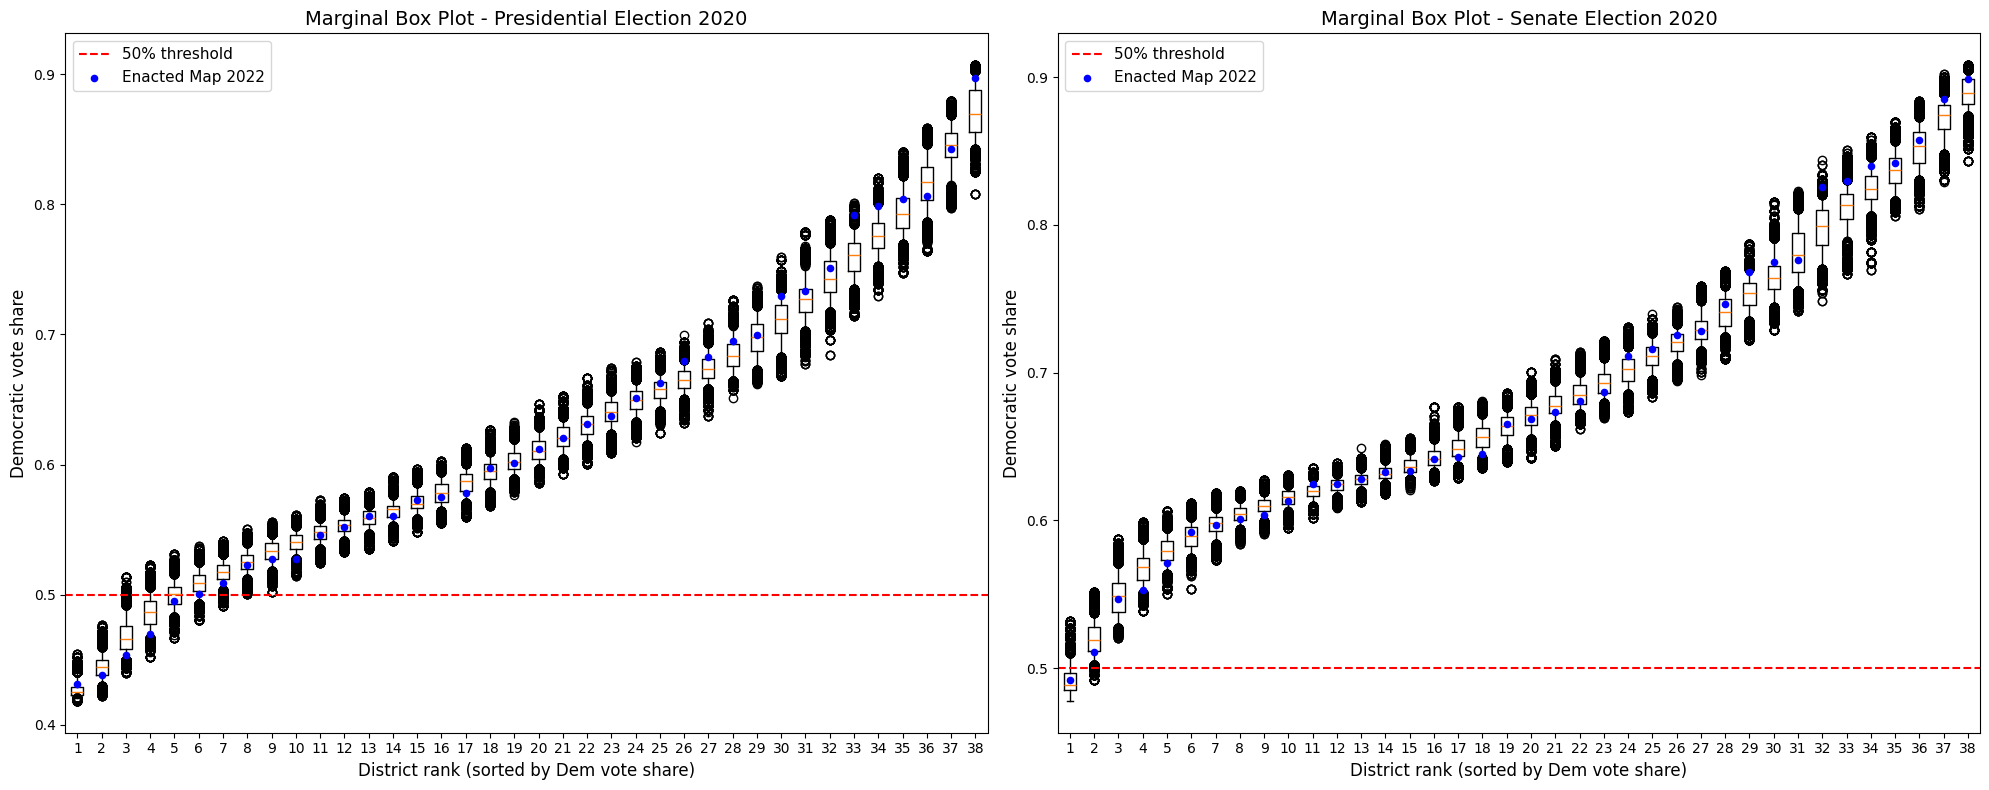

In [18]:
# Marginal box plots - "signature of gerrymandering"
# Each box shows the distribution of Dem vote share for one district rank
# across all steps in the ensemble.
pres_district_shares = []
sen_district_shares  = []

boxplot_walk = MarkovChain(
    proposal=rw_proposal,
    constraints=[population_constraint],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=10000
)

for part in boxplot_walk:
    pres_results = part["Pres20"]
    sen_results  = part["Sen20"]

    pres_shares = sorted(pres_results.percents("Dem"))
    sen_shares  = sorted(sen_results.percents("Dem"))

    pres_district_shares.append(pres_shares)
    sen_district_shares.append(sen_shares)

# Transpose: each element = all values for one district rank across chain steps
pres_by_rank = list(zip(*pres_district_shares))
sen_by_rank  = list(zip(*sen_district_shares))

num_districts = len(pres_by_rank)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')
# Presidential
axes[0].boxplot(pres_by_rank, positions=range(1, num_districts + 1), whis=[5, 95])
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[0].set_xlabel("District rank (sorted by Dem vote share)", fontsize=12)
axes[0].set_ylabel("Democratic vote share", fontsize=12)
axes[0].set_title("Marginal Box Plot - Presidential Election 2020", fontsize=14)


# Senate
axes[1].boxplot(sen_by_rank, positions=range(1, num_districts + 1), whis=[5, 95])
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[1].set_xlabel("District rank (sorted by Dem vote share)", fontsize=12)
axes[1].set_ylabel("Democratic vote share", fontsize=12)
axes[1].set_title("Marginal Box Plot - Senate Election 2020", fontsize=14)
axes[1].legend(fontsize=11)

# Add real percentage points on enacted map
enacted_pres_shares = sorted(initial_partition["Pres20"].percents("Dem"))
enacted_sen_shares  = sorted(initial_partition["Sen20"].percents("Dem"))

axes[0].scatter(range(1, num_districts + 1), enacted_pres_shares, 
                color='blue', marker='o', s=20, label='Enacted Map 2022', zorder=5)
axes[1].scatter(range(1, num_districts + 1), enacted_sen_shares, 
                color='blue', marker='o', s=20, label='Enacted Map 2022', zorder=5)

axes[0].legend(fontsize=11)
axes[1].legend(fontsize=11)



plt.tight_layout()
plt.show()

The enacted map's data points (blue dots) largely fall within the interquartile range (IQR) of the simulated ensemble. There are minor deviations in specific district ranks, but these remain within the range of expected variation for a neutral plan.

Link of our report: 
https://www.overleaf.com/read/jrvnhrhkfddv#722213